# Block E analysis — one network per step length, chained to itself

This notebook **loads** the tables and figures the E3 scripts wrote; it computes nothing.
Every number comes from `results/*.csv` and every figure from `figures/*.png`.

The error is the **radial** distance at the first SciFi plane, z1 = 7,826 mm,
between the network's endpoint and the RK6 endpoint of the same track:
r = sqrt(dx^2 + dy^2), on the 1,452 test tracks.

Training was stopped by hand on 2026-09-18: the loss on freshly drawn states and the
validation error had both been flat for ten rounds.

In [1]:
import pandas as pd, os
from IPython.display import Image, display
pd.set_option("display.width", 200, "display.max_columns", 50)
R = lambda n: pd.read_csv(os.path.join("results", n))
F = lambda n: display(Image(os.path.join("figures", n)))

## 1. error(q, dz) for the chains, and for a single step

,N,q,dz_mm,med_um,p95_um,p99_um,exact_med_um,block_d_med_um,us_per_track,val_rounds_mean_um,val_rounds_std_um
0,2,2,2588.90,9249.998624,39346.582505,70103.887156,9270.907661,NaN,26.4,9582.274090,43.209307
1,2,4,2588.90,283.817941,2011.453367,5413.807695,195.401900,NaN,26.0,272.434731,1.395625
2,2,8,2588.90,188.141188,1427.675531,4355.291074,7.472217,NaN,26.5,173.059669,1.660160
3,2,16,2588.90,223.648103,1682.846258,3708.324818,5.167053,NaN,28.4,210.102024,2.409718
4,64,2,80.90,166.258188,1153.923664,3303.553168,0.146544,2304.339087,803.2,127.198156,11.142667
5,64,4,80.90,172.370292,1050.735464,2915.351199,0.478288,2442.121594,813.9,133.726555,10.571053
6,64,8,80.90,204.152170,1248.723347,3789.881549,0.103011,2346.397111,833.4,145.599520,8.257456
7,64,16,80.90,194.156949,1207.240404,3914.343001,0.071889,2417.861042,888.4,169.481436,9.984038
8,128,2,40.45,207.010342,1206.245231,3779.418296,0.510653,2939.592765,1592.3,137.345238,8.724242
9,128,4,40.45,195.612624,1246.483358,4215.322788,0.115904,3295.891079,1657.6,146.038510,7.374070


,what,med_um,p95_um,p99_um,mean_um,max_um,frac_above_1mm,worst5pct_share,n
0,straight line,450541.744575,1.252354e+06,1.448745e+06,532052.830255,1.832614e+06,1.000000,0.130619,1452
1,material floor (real SciFi state vs the RK6 tr...,1896.348151,1.343206e+04,3.018207e+04,3930.303541,1.176342e+05,0.665978,0.322064,1452


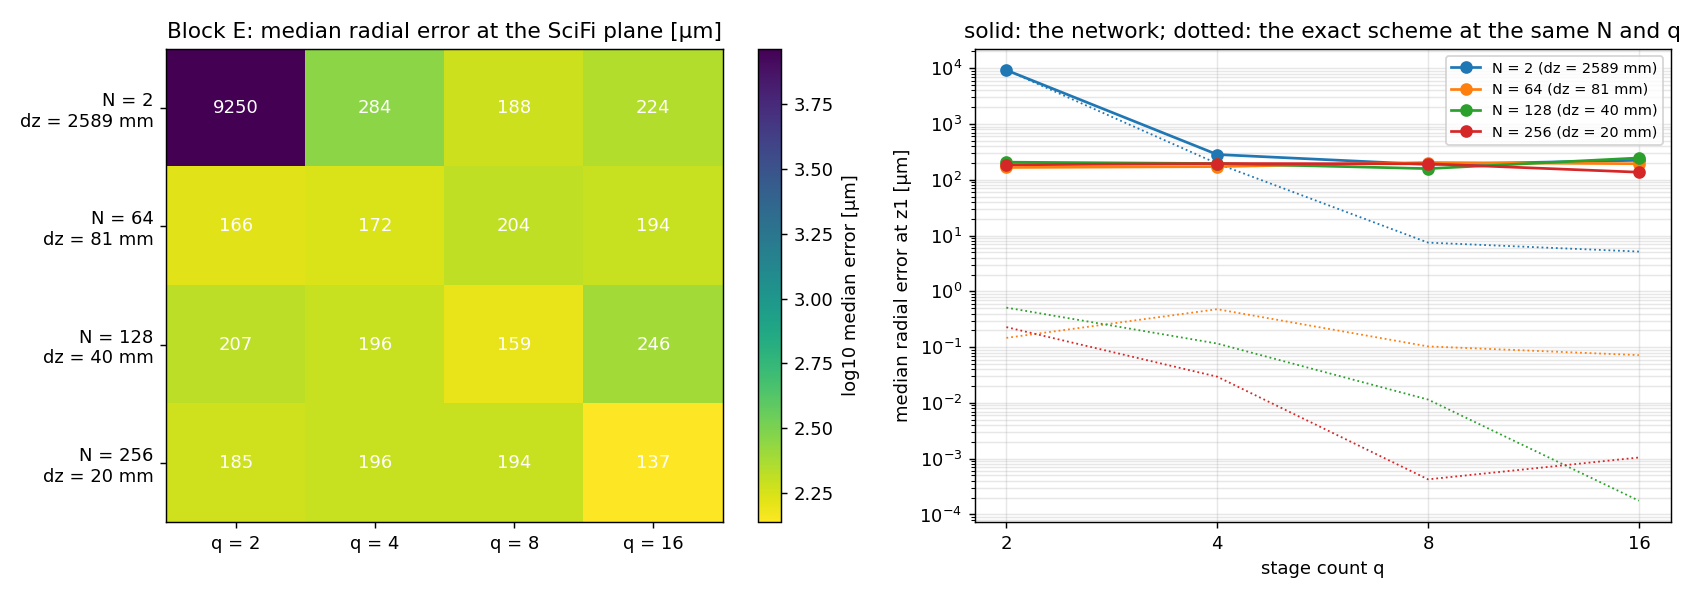

In [2]:
chain = R("error_qdz_chain.csv")
display(chain[["N","q","dz_mm","med_um","p95_um","p99_um","exact_med_um","block_d_med_um","us_per_track",
               "val_rounds_mean_um","val_rounds_std_um"]].sort_values(["N","q"]))
display(R("comparators.csv"))
F("error_qdz.png")

,N,q,dz_mm,step_med_um,step_p95_um,straight_line_step_med_um,step_over_straight,chain_med_um
0,2,2,2588.90,1430.844429,13389.794552,105150.426735,0.013608,9249.493664
1,2,4,2588.90,92.456581,646.343193,105150.426735,0.000879,260.919285
2,2,8,2588.90,62.531522,448.837351,105150.426735,0.000595,168.449277
3,2,16,2588.90,72.812031,538.769226,105150.426735,0.000692,201.927552
4,64,2,80.90,0.415098,2.574506,95.221188,0.004359,152.044635
5,64,4,80.90,0.556816,3.302673,95.221188,0.005848,161.794502
6,64,8,80.90,0.647698,3.820560,95.221188,0.006802,192.038260
7,64,16,80.90,0.810344,5.220217,95.221188,0.008510,172.734321
8,128,2,40.45,0.150871,1.130535,23.817459,0.006334,189.892722
9,128,4,40.45,0.256727,1.550990,23.817459,0.010779,174.460889


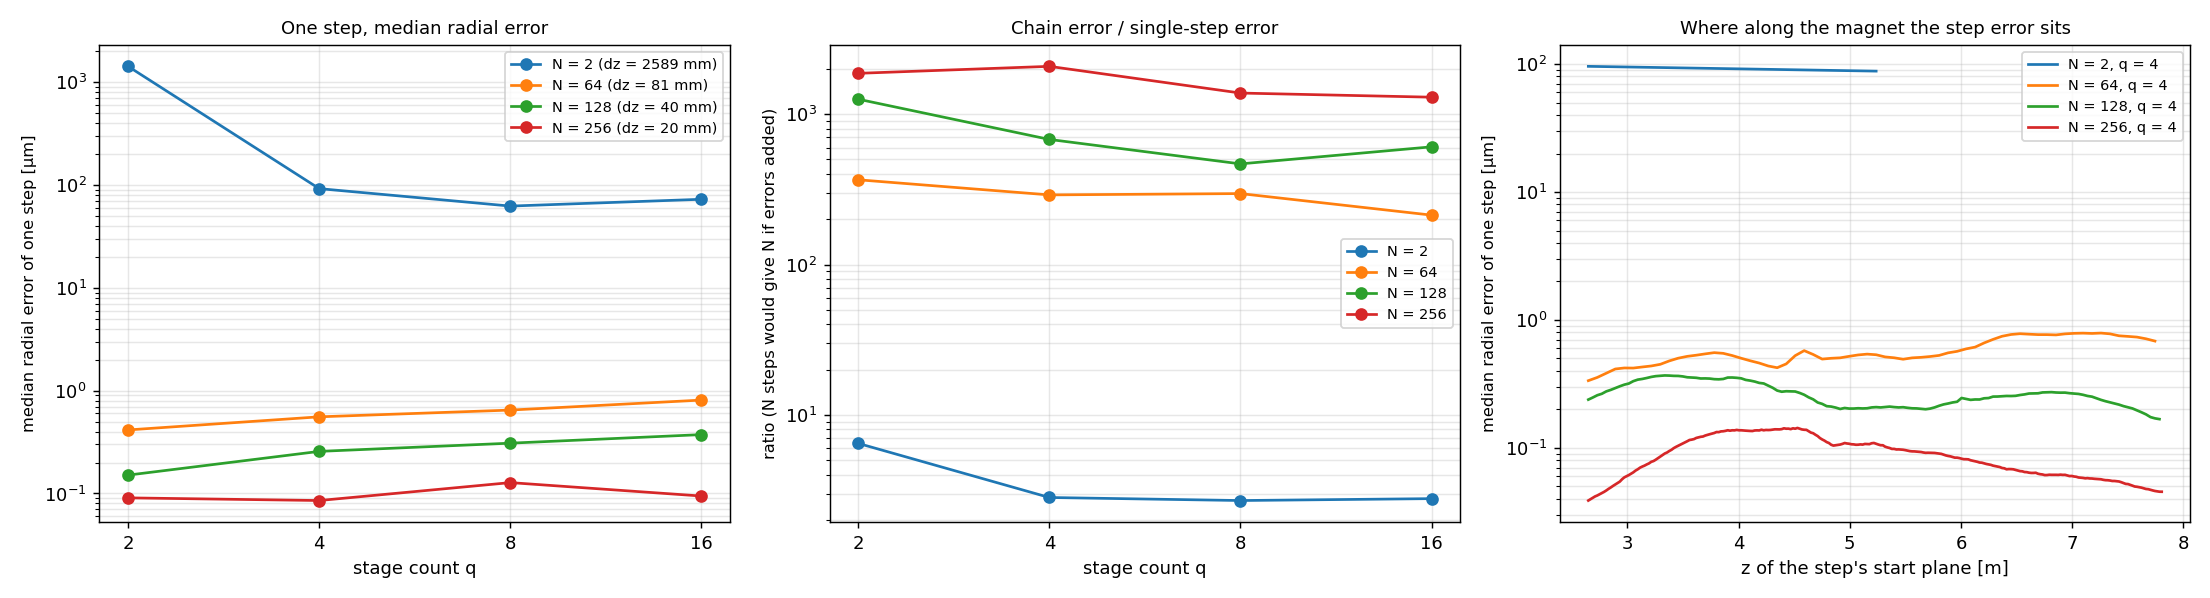

In [3]:
step = R("error_qdz_single_step.csv")
display(step[["N","q","dz_mm","step_med_um","step_p95_um","straight_line_step_med_um",
              "step_over_straight","chain_med_um"]].sort_values(["N","q"]))
F("single_step.png")

## 2. Where the error is built up, and the tails

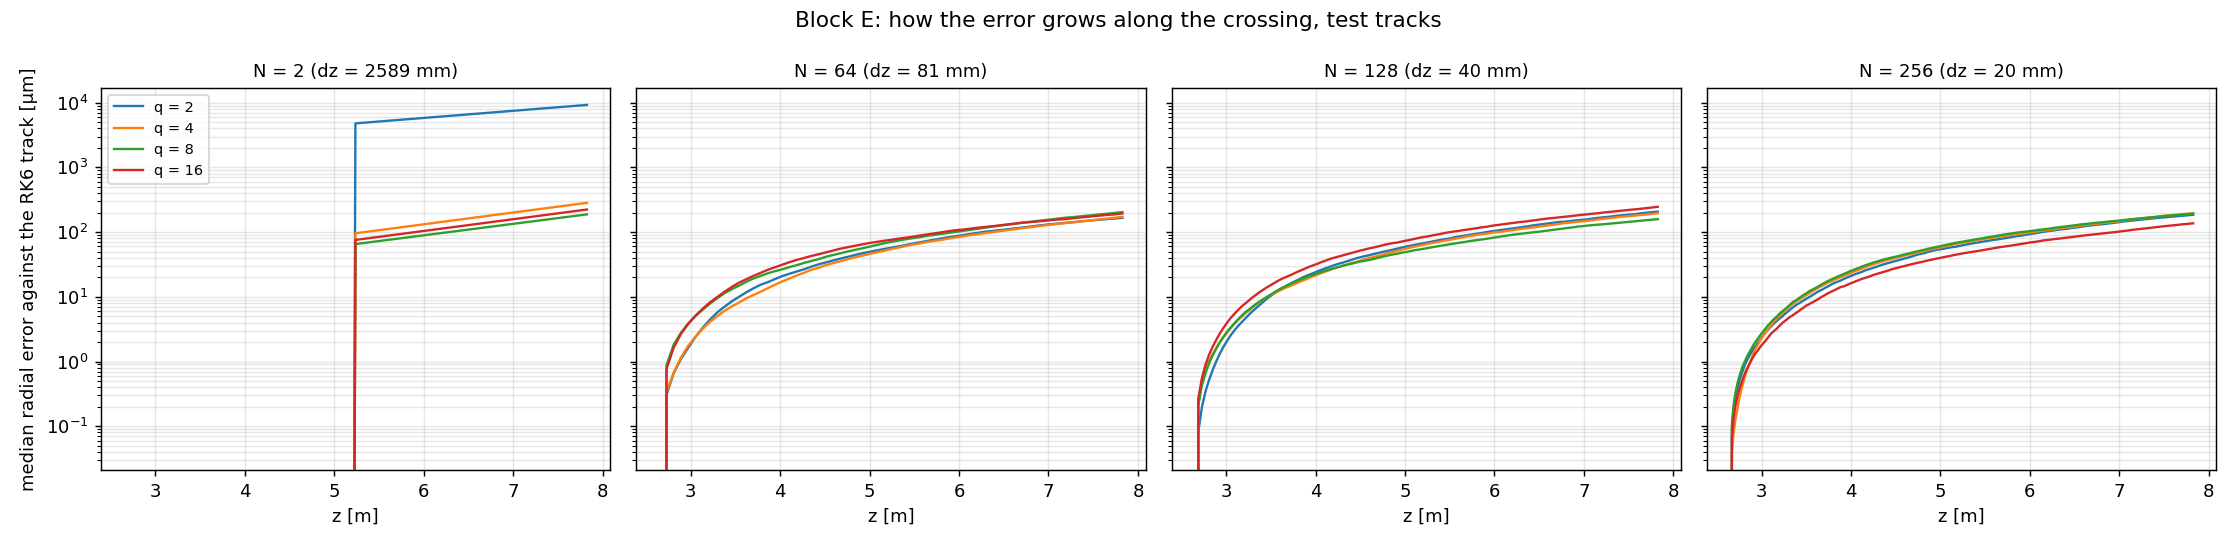

,N,q,med_um,p95_um,p99_um,max_um,frac_above_1mm,worst5pct_share
15,256,16,136.778692,1082.143054,3605.671538,31383.926385,0.059229,0.476293
10,128,8,158.561260,1089.638767,4042.591077,10959.304638,0.057163,0.417245
4,64,2,166.258188,1153.923664,3303.553168,24984.761738,0.062672,0.416889
5,64,4,172.370292,1050.735464,2915.351199,23331.146120,0.055096,0.394173
12,256,2,185.301079,1318.890520,3409.601853,19661.179360,0.068871,0.384688
2,2,8,188.141188,1427.675531,4355.291074,23286.135466,0.079201,0.434841
14,256,8,193.572401,1203.730967,3090.087776,20298.002418,0.064050,0.363637
7,64,16,194.156949,1207.240404,3914.343001,21310.306351,0.070248,0.400348
13,256,4,195.570503,1275.482609,4842.899129,30867.466690,0.068182,0.437461
9,128,4,195.612624,1246.483358,4215.322788,16143.939000,0.066804,0.406869


,N,q,us_per_track,med_um,n_parameters
15,256,16,3546.2,136.778692,26180
10,128,8,1693.4,158.561260,22052
4,64,2,803.2,166.258188,18956
5,64,4,813.9,172.370292,19988
12,256,2,3262.6,185.301079,18956
2,2,8,26.5,188.141188,22052
14,256,8,3324.6,193.572401,22052
7,64,16,888.4,194.156949,26180
13,256,4,3311.5,195.570503,19988
9,128,4,1657.6,195.612624,19988


In [4]:
F("error_vs_z.png"); display(R("tails.csv").sort_values("med_um")); display(R("cost_accuracy.csv").sort_values("med_um"))

## 3. Every model: each component of the state against momentum

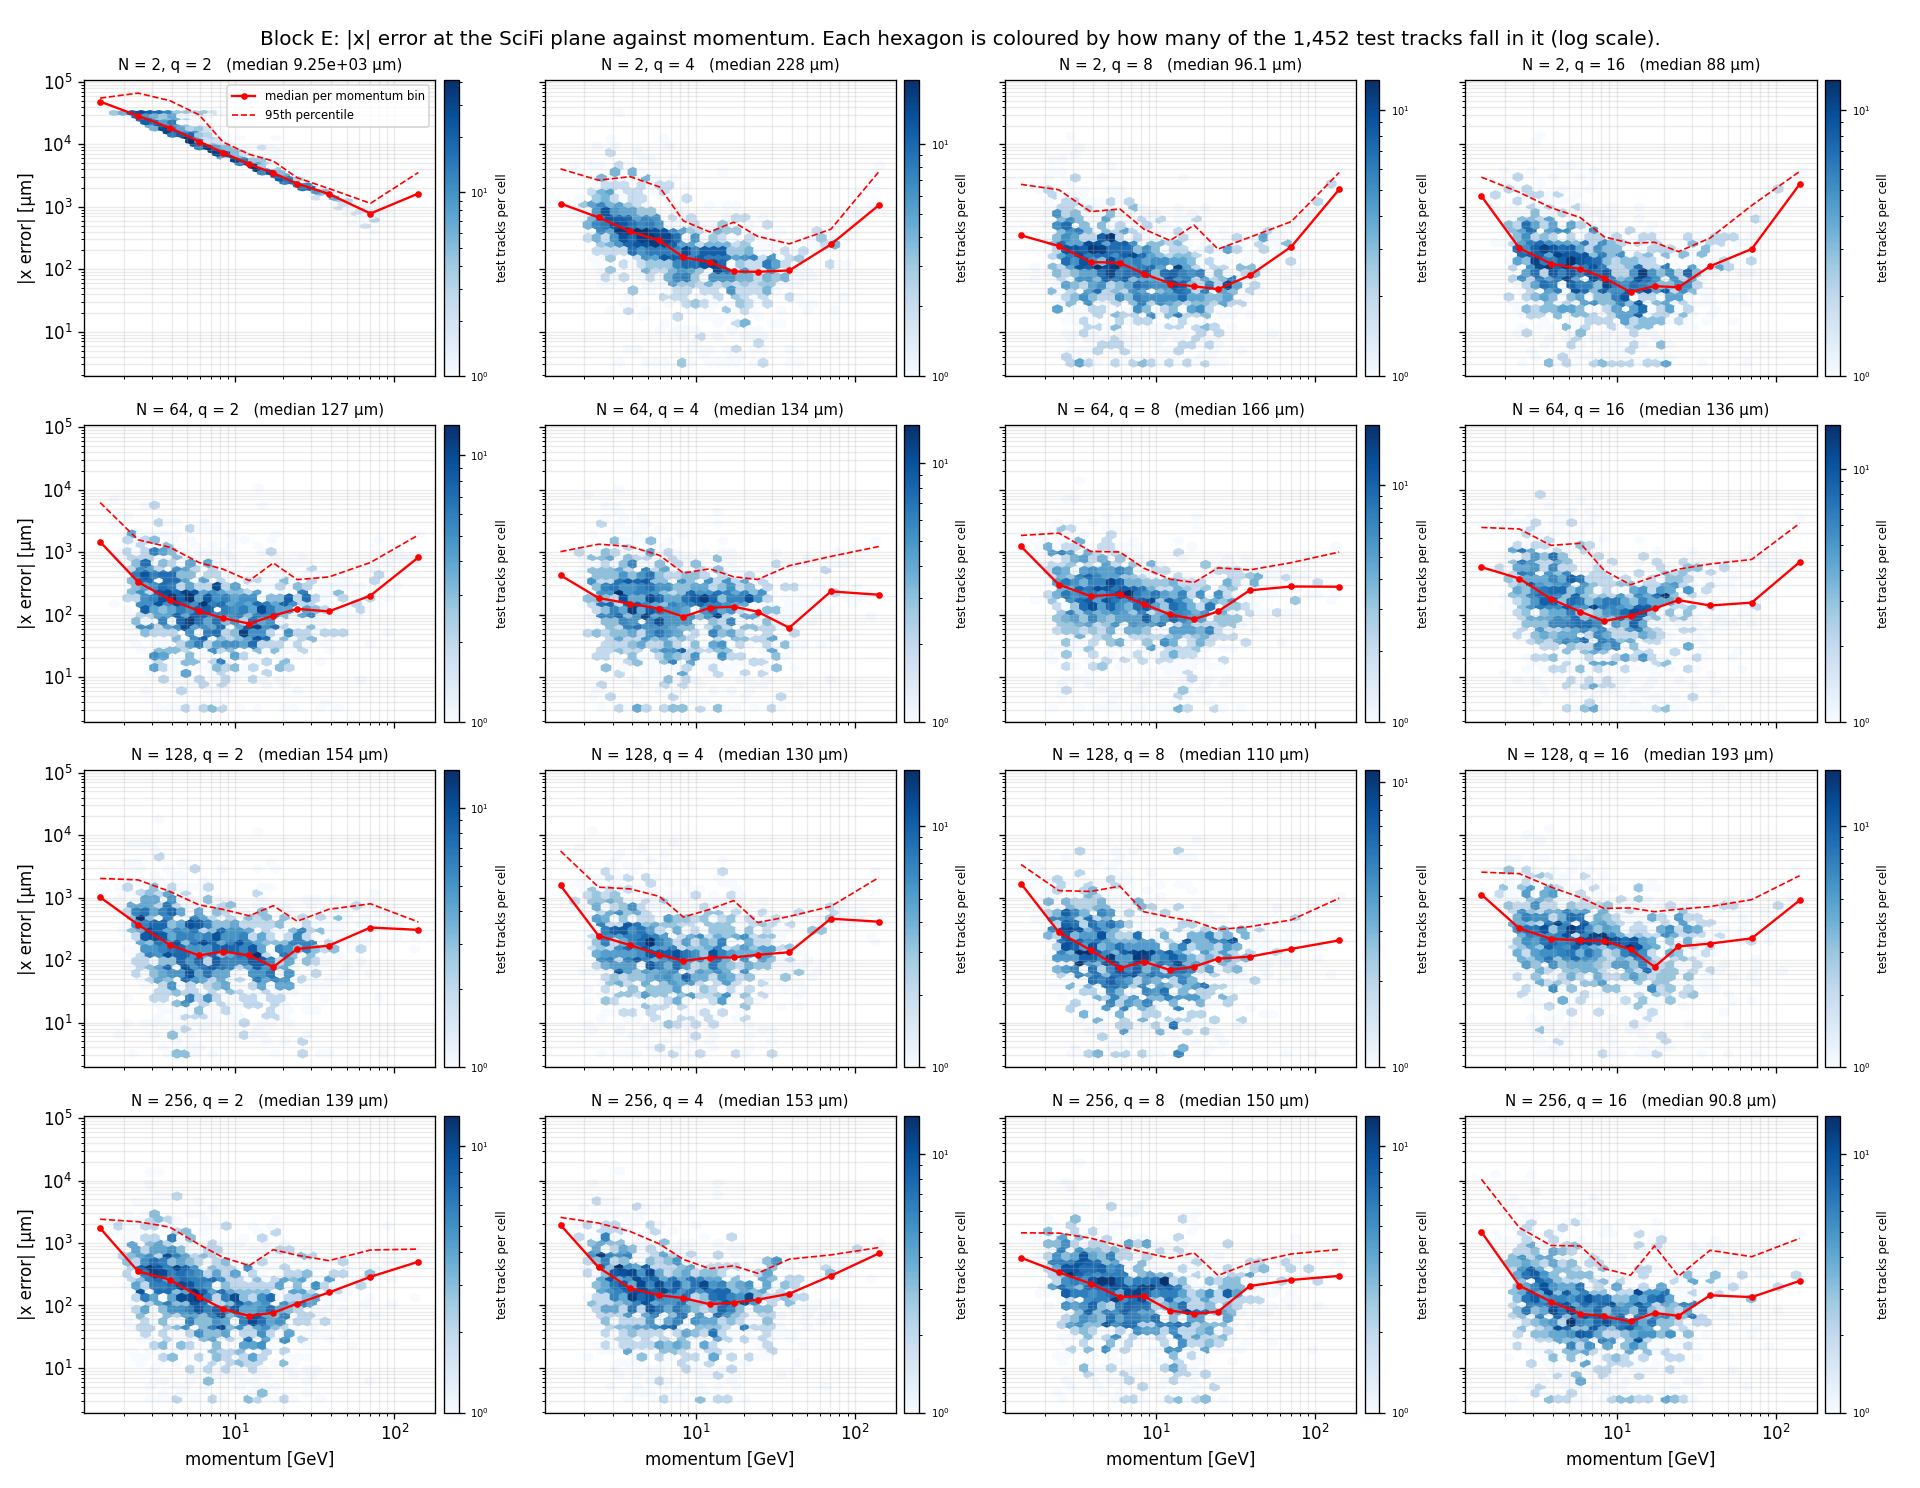

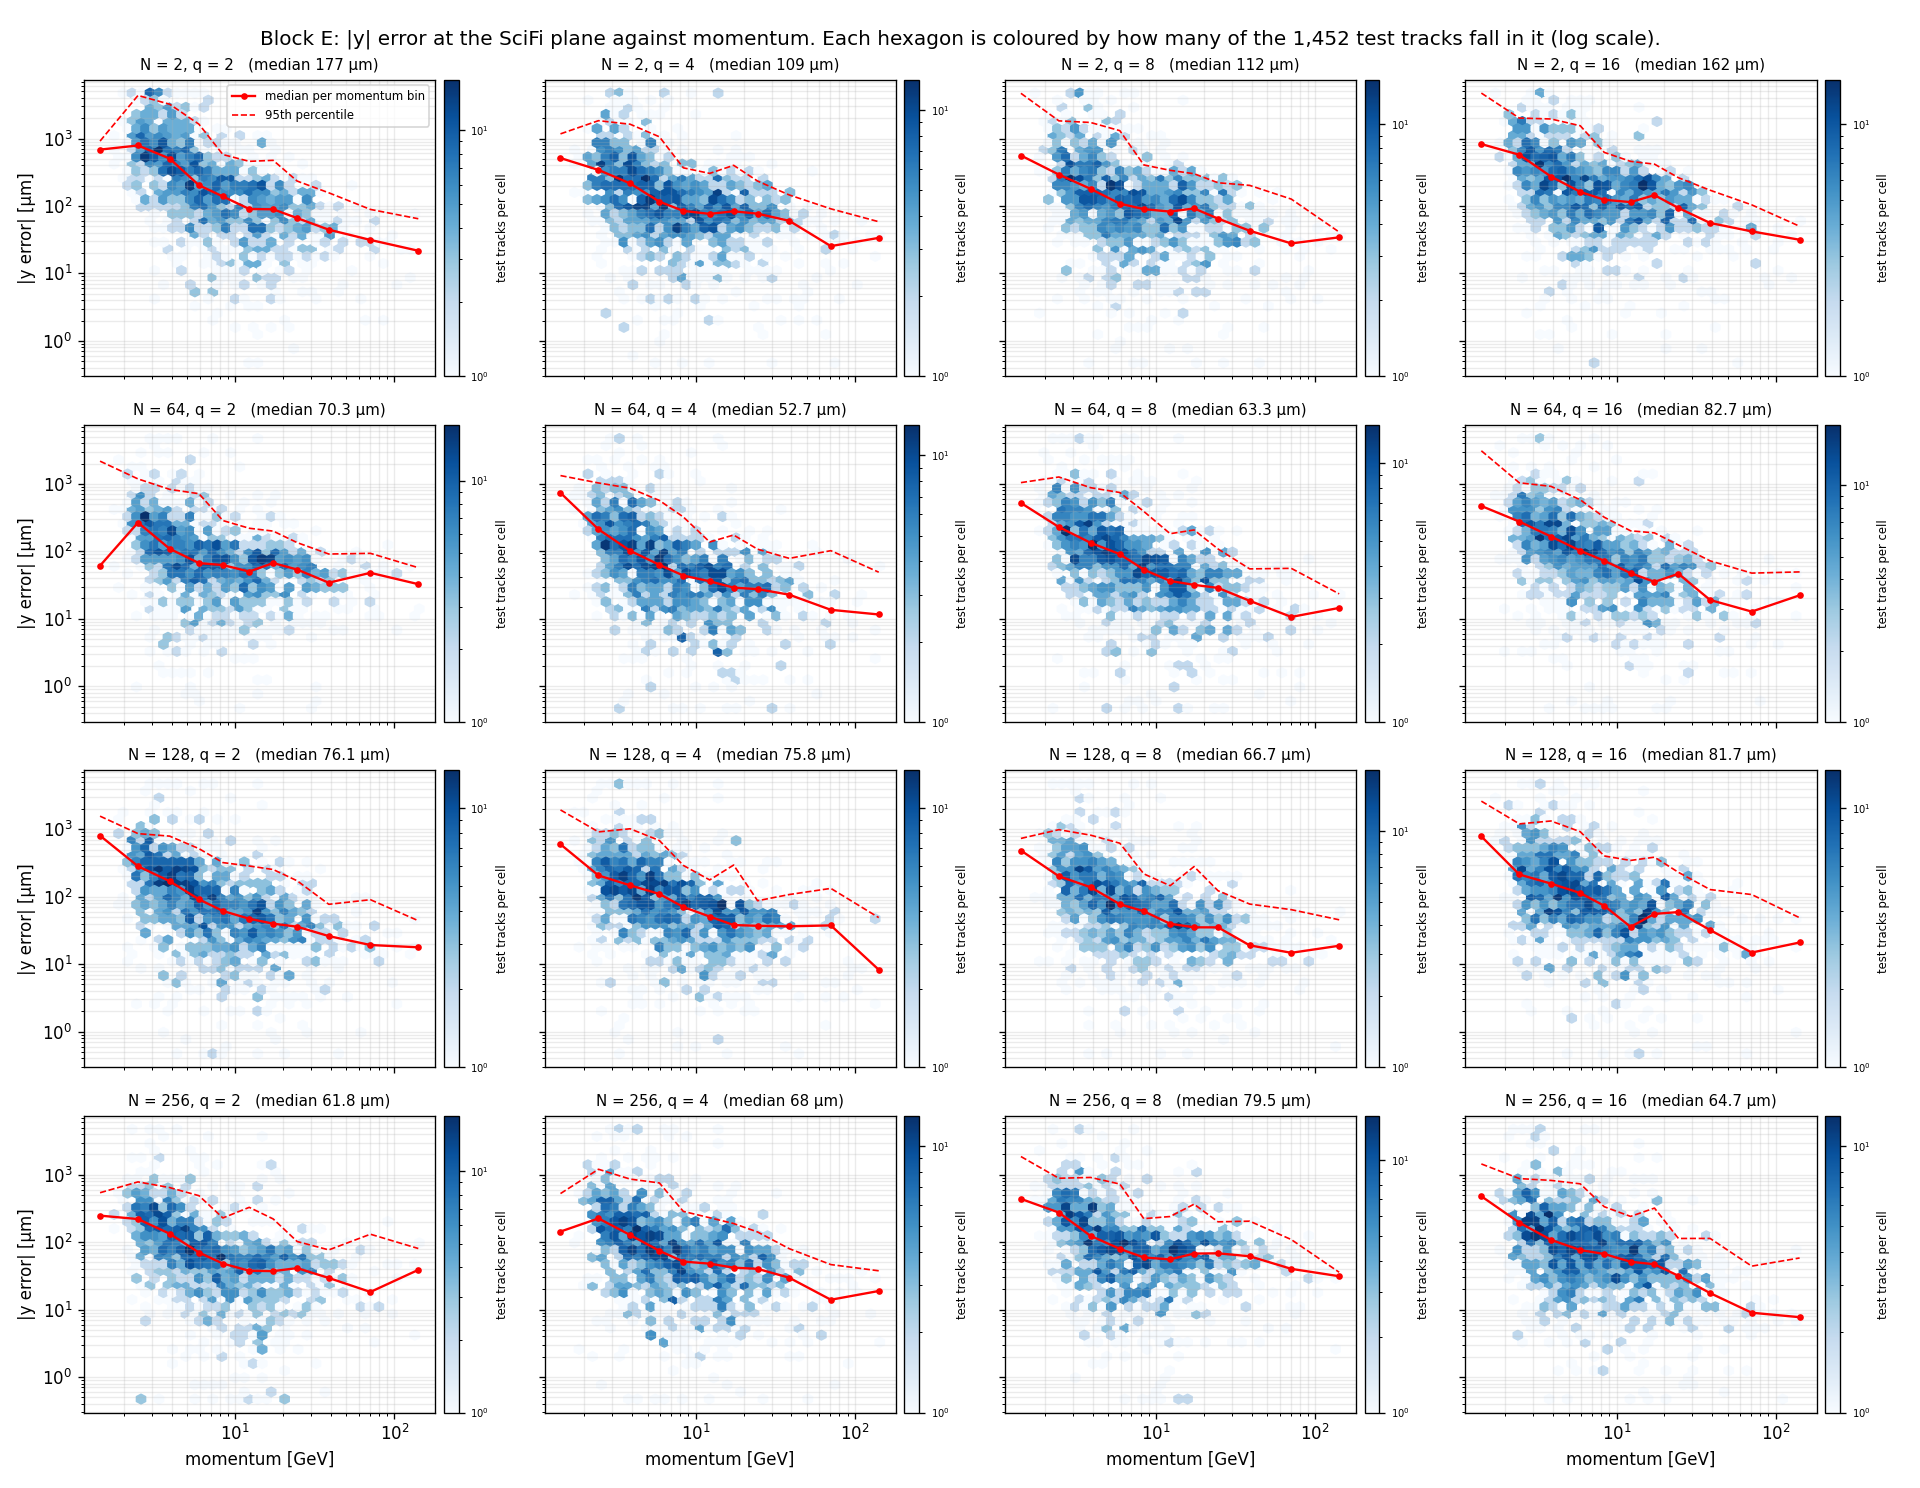

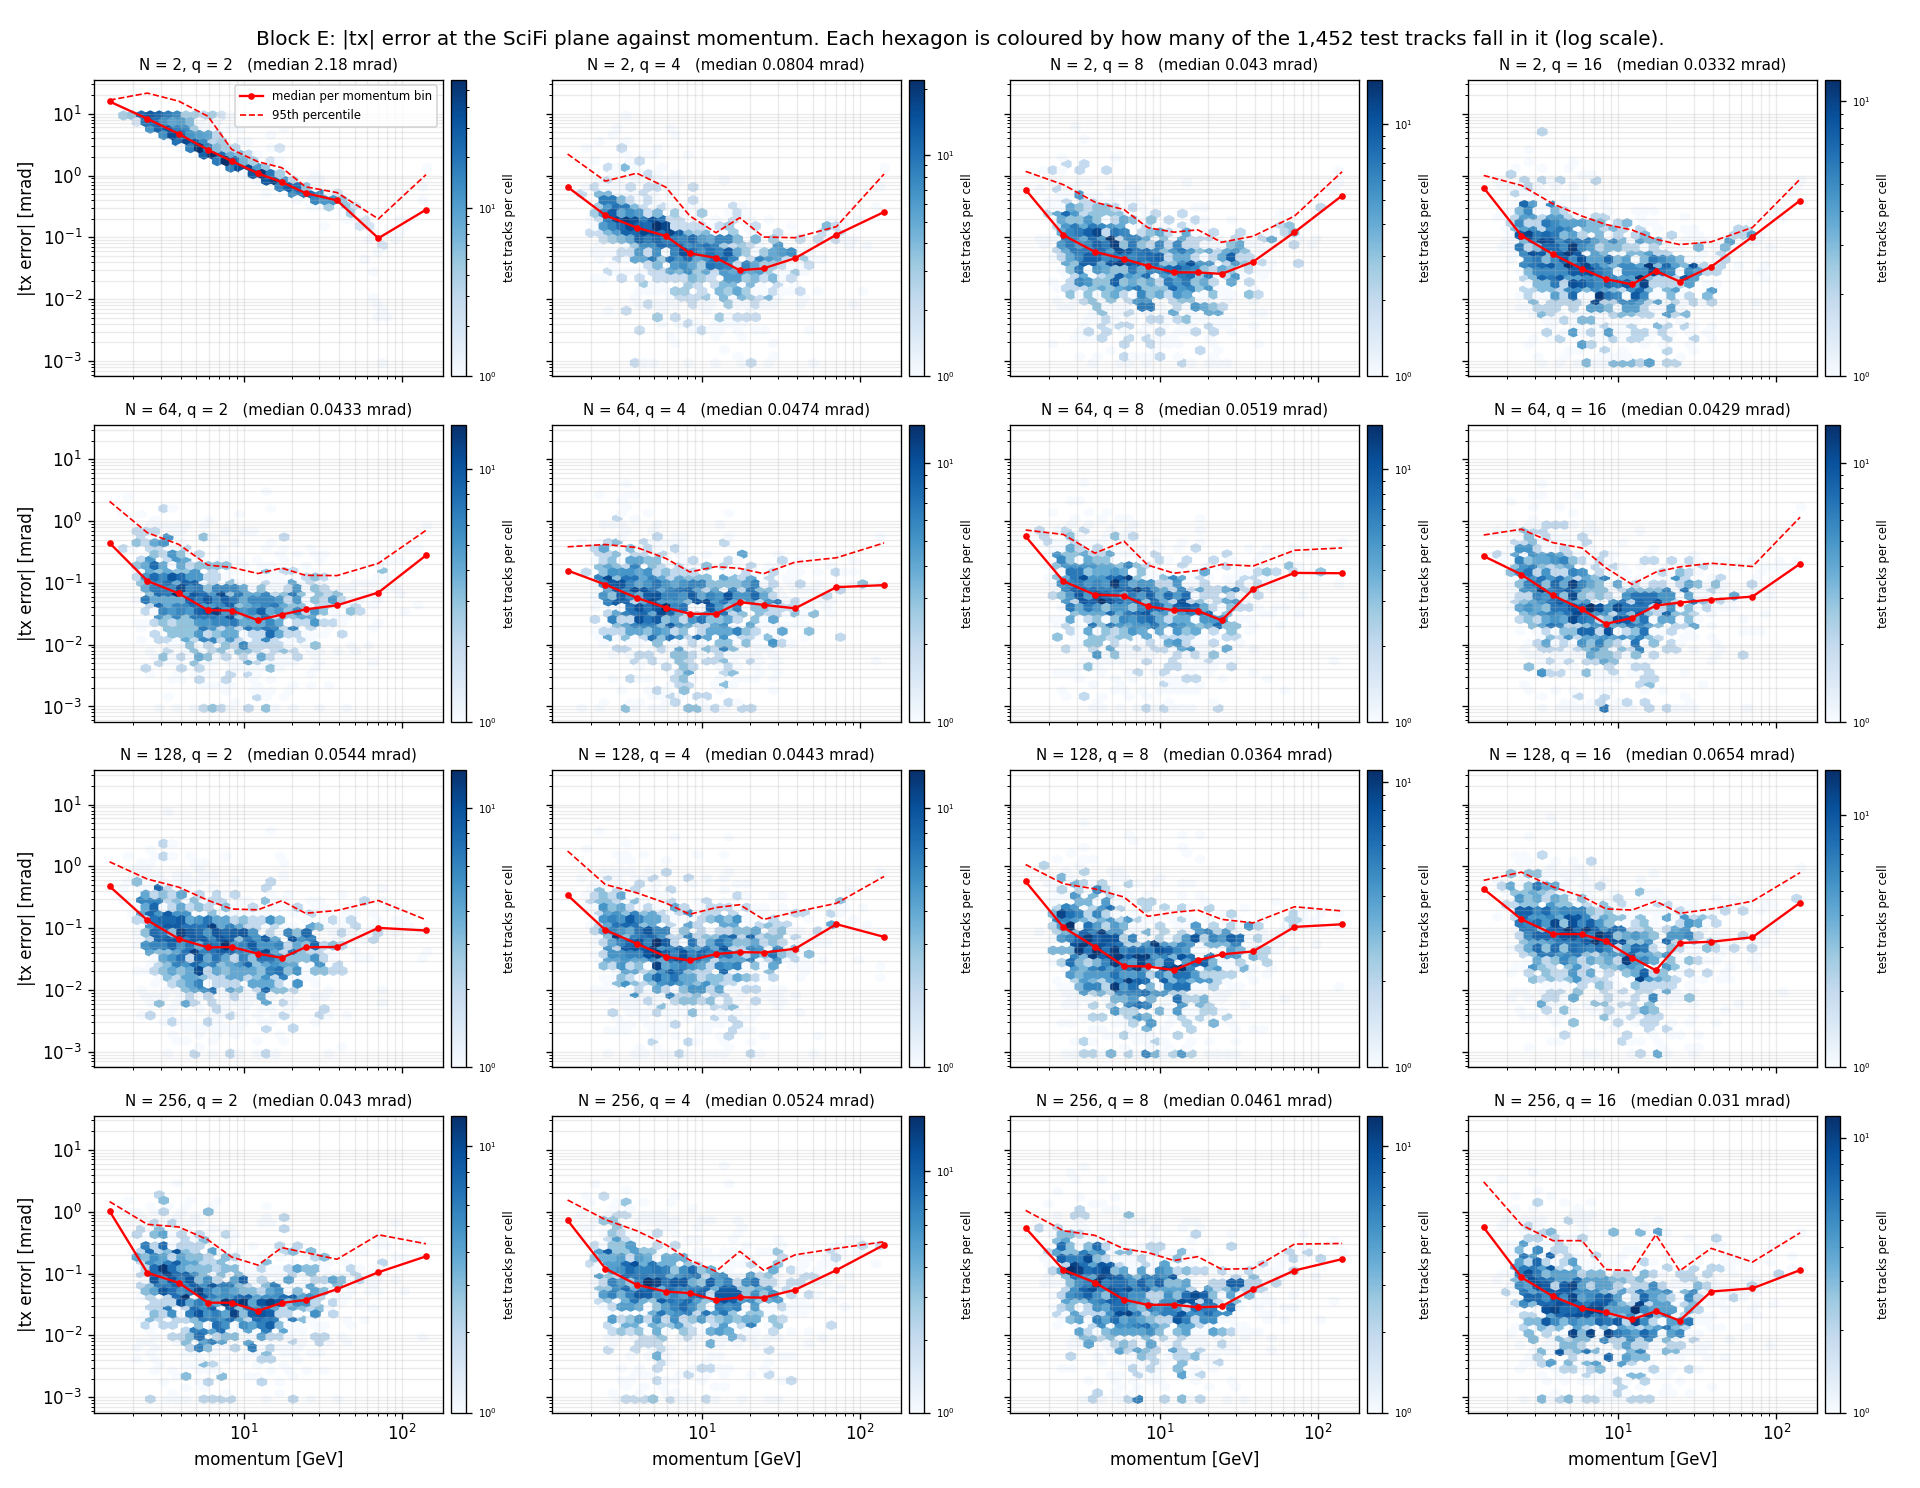

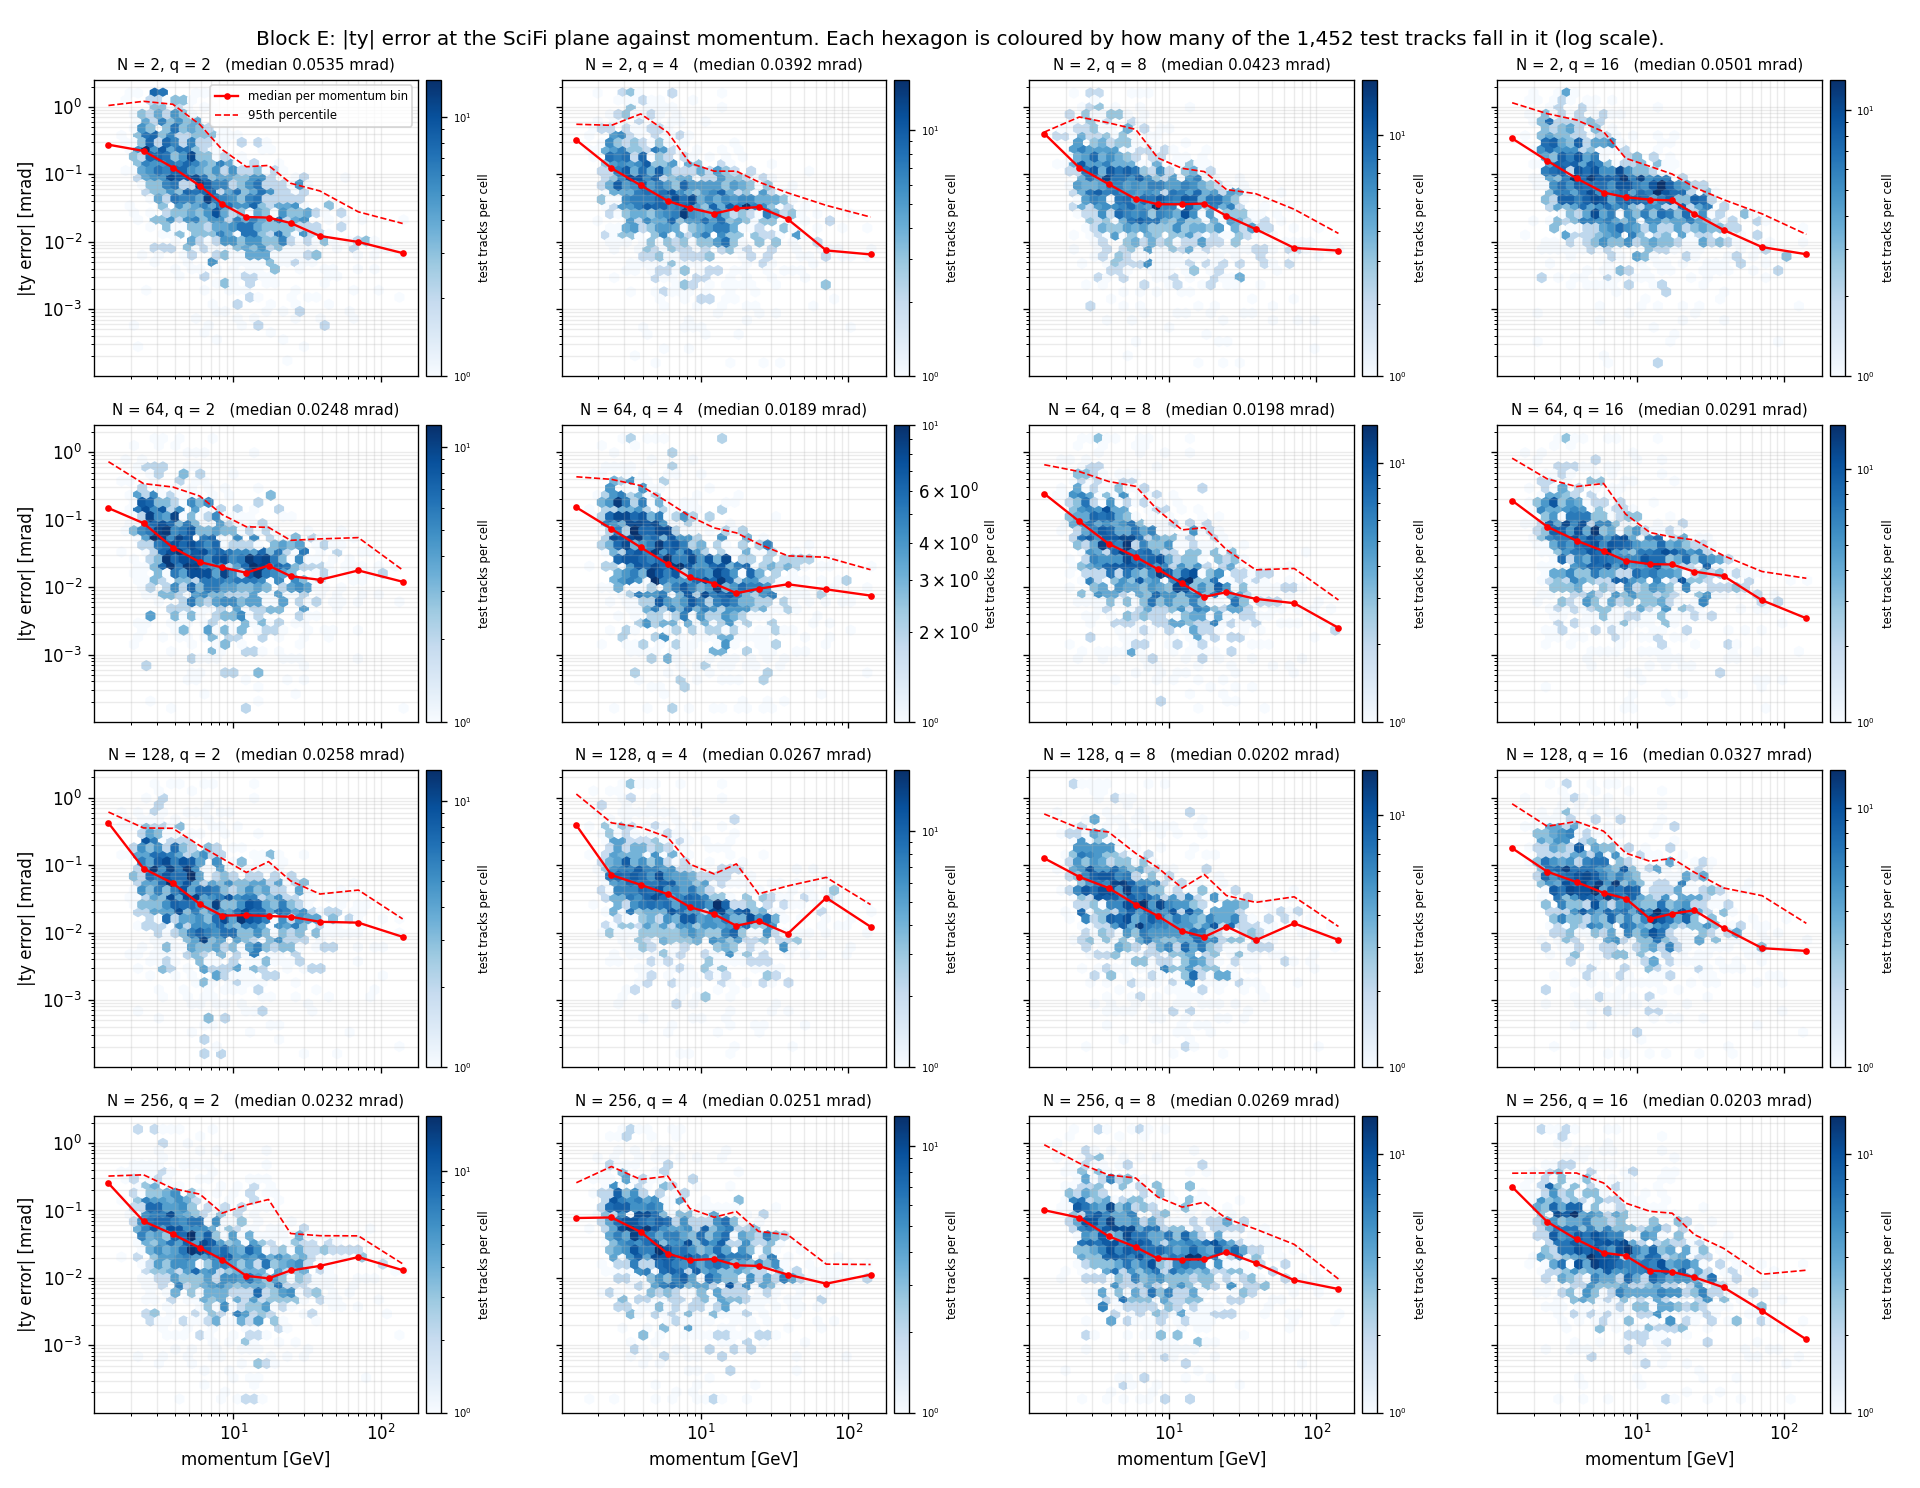

,N,q,component,unit,p_lo,p_hi,n,med,p95,signed_mean
0,2,2,x,µm,1.0,2.0,5,48315.613800,54896.043912,27584.527160
1,2,2,x,µm,2.0,3.0,159,28607.685618,66085.447907,-1755.962851
2,2,2,x,µm,3.0,5.0,341,18417.251713,50048.411905,243.606480
3,2,2,x,µm,5.0,7.0,233,11090.921149,29755.619480,-617.205224
4,2,2,x,µm,7.0,10.0,197,7392.604415,10899.993761,472.560276


In [5]:
for c in ("x","y","tx","ty"): F("error_vs_p_%s.png" % c)
R("error_vs_p.csv").head()

## 4. Convergence: the training loss and the error it buys

,N,q,restarts,rounds,loss_first,loss_final,loss_end_first,loss_end_last,loss_end_last8_ratio,val_first,val_final,val_last8_mean,val_last8_std,val_best,val_best_round,test_final
0,2,2,109,6,1.183450e-04,1.184363e-06,5.115583e-06,1.193406e-06,4.286540,9515.552845,9566.372488,9582.274090,43.209307,9515.552845,1,9249.493664
1,2,4,159,19,1.169284e-04,9.888551e-07,4.236148e-06,9.911515e-07,1.038074,404.719091,271.664757,272.434731,1.395625,270.101450,9,260.919285
2,2,8,130,17,1.035610e-04,1.271533e-06,3.809722e-06,1.275505e-06,1.047153,346.775939,170.298028,173.059669,1.660160,170.298028,17,168.449277
3,2,16,106,16,1.158567e-04,1.262374e-06,2.519344e-06,1.266196e-06,1.055614,376.839889,206.125851,210.102024,2.409718,206.125851,16,201.927552
4,64,2,760,30,1.517389e-07,1.098279e-09,3.709954e-09,4.362461e-10,1.277955,346.954190,111.574008,127.198156,11.142667,111.574008,30,152.044635
5,64,4,714,28,1.406571e-07,7.113091e-10,3.507718e-09,5.874732e-10,0.968823,399.828880,158.425619,133.726555,10.571053,119.788987,22,161.794502
6,64,8,657,26,1.303311e-07,1.133141e-09,3.590907e-09,4.344339e-10,1.566804,424.034868,132.976865,145.599520,8.257456,130.790918,14,192.038260
7,64,16,546,21,1.412326e-07,7.168592e-10,4.026685e-09,7.215223e-10,0.778134,430.130478,185.266809,169.481436,9.984038,156.936354,19,172.734321
8,128,2,760,30,3.692851e-08,2.708808e-10,9.153387e-10,1.292318e-10,1.397338,388.337819,143.210073,137.345238,8.724242,127.224885,26,189.892722
9,128,4,713,28,3.480726e-08,2.577625e-10,9.572650e-10,1.822280e-10,0.974305,425.314269,145.248959,146.038510,7.374070,134.618915,26,174.460889


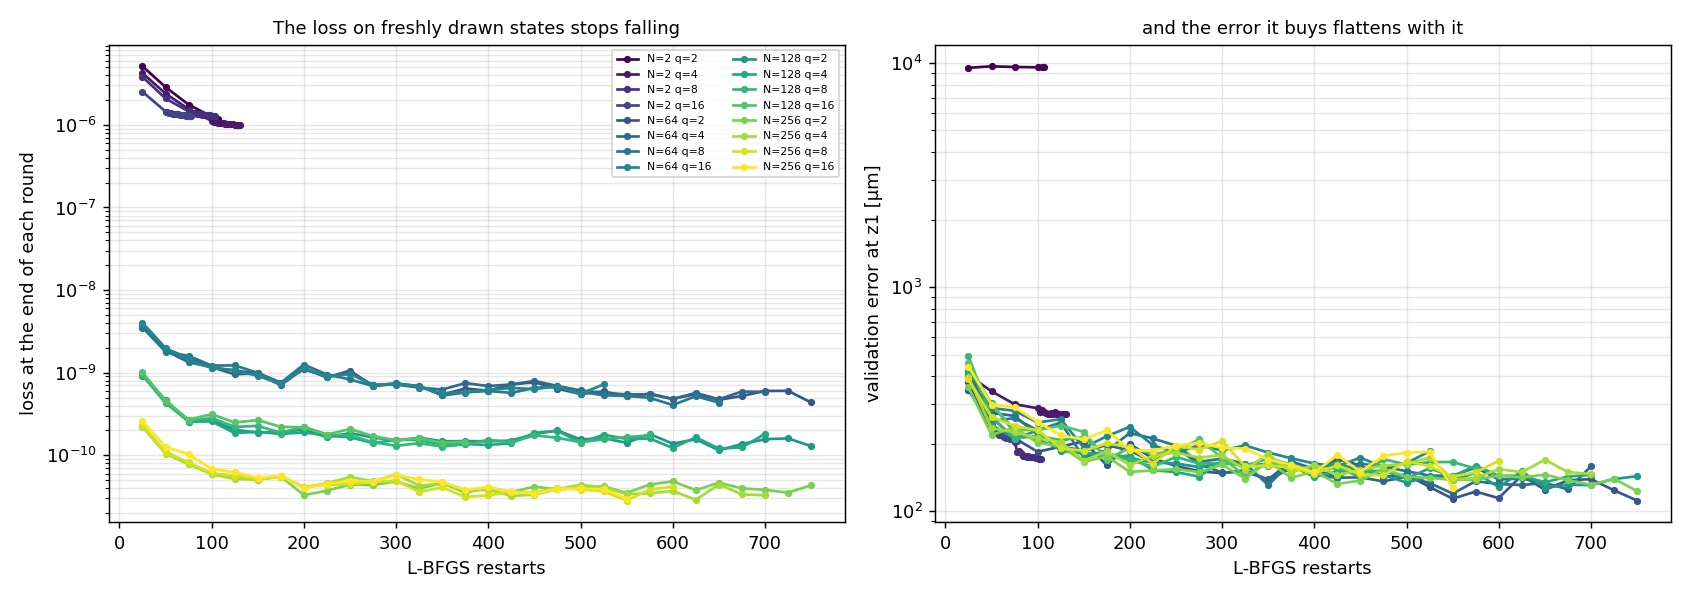

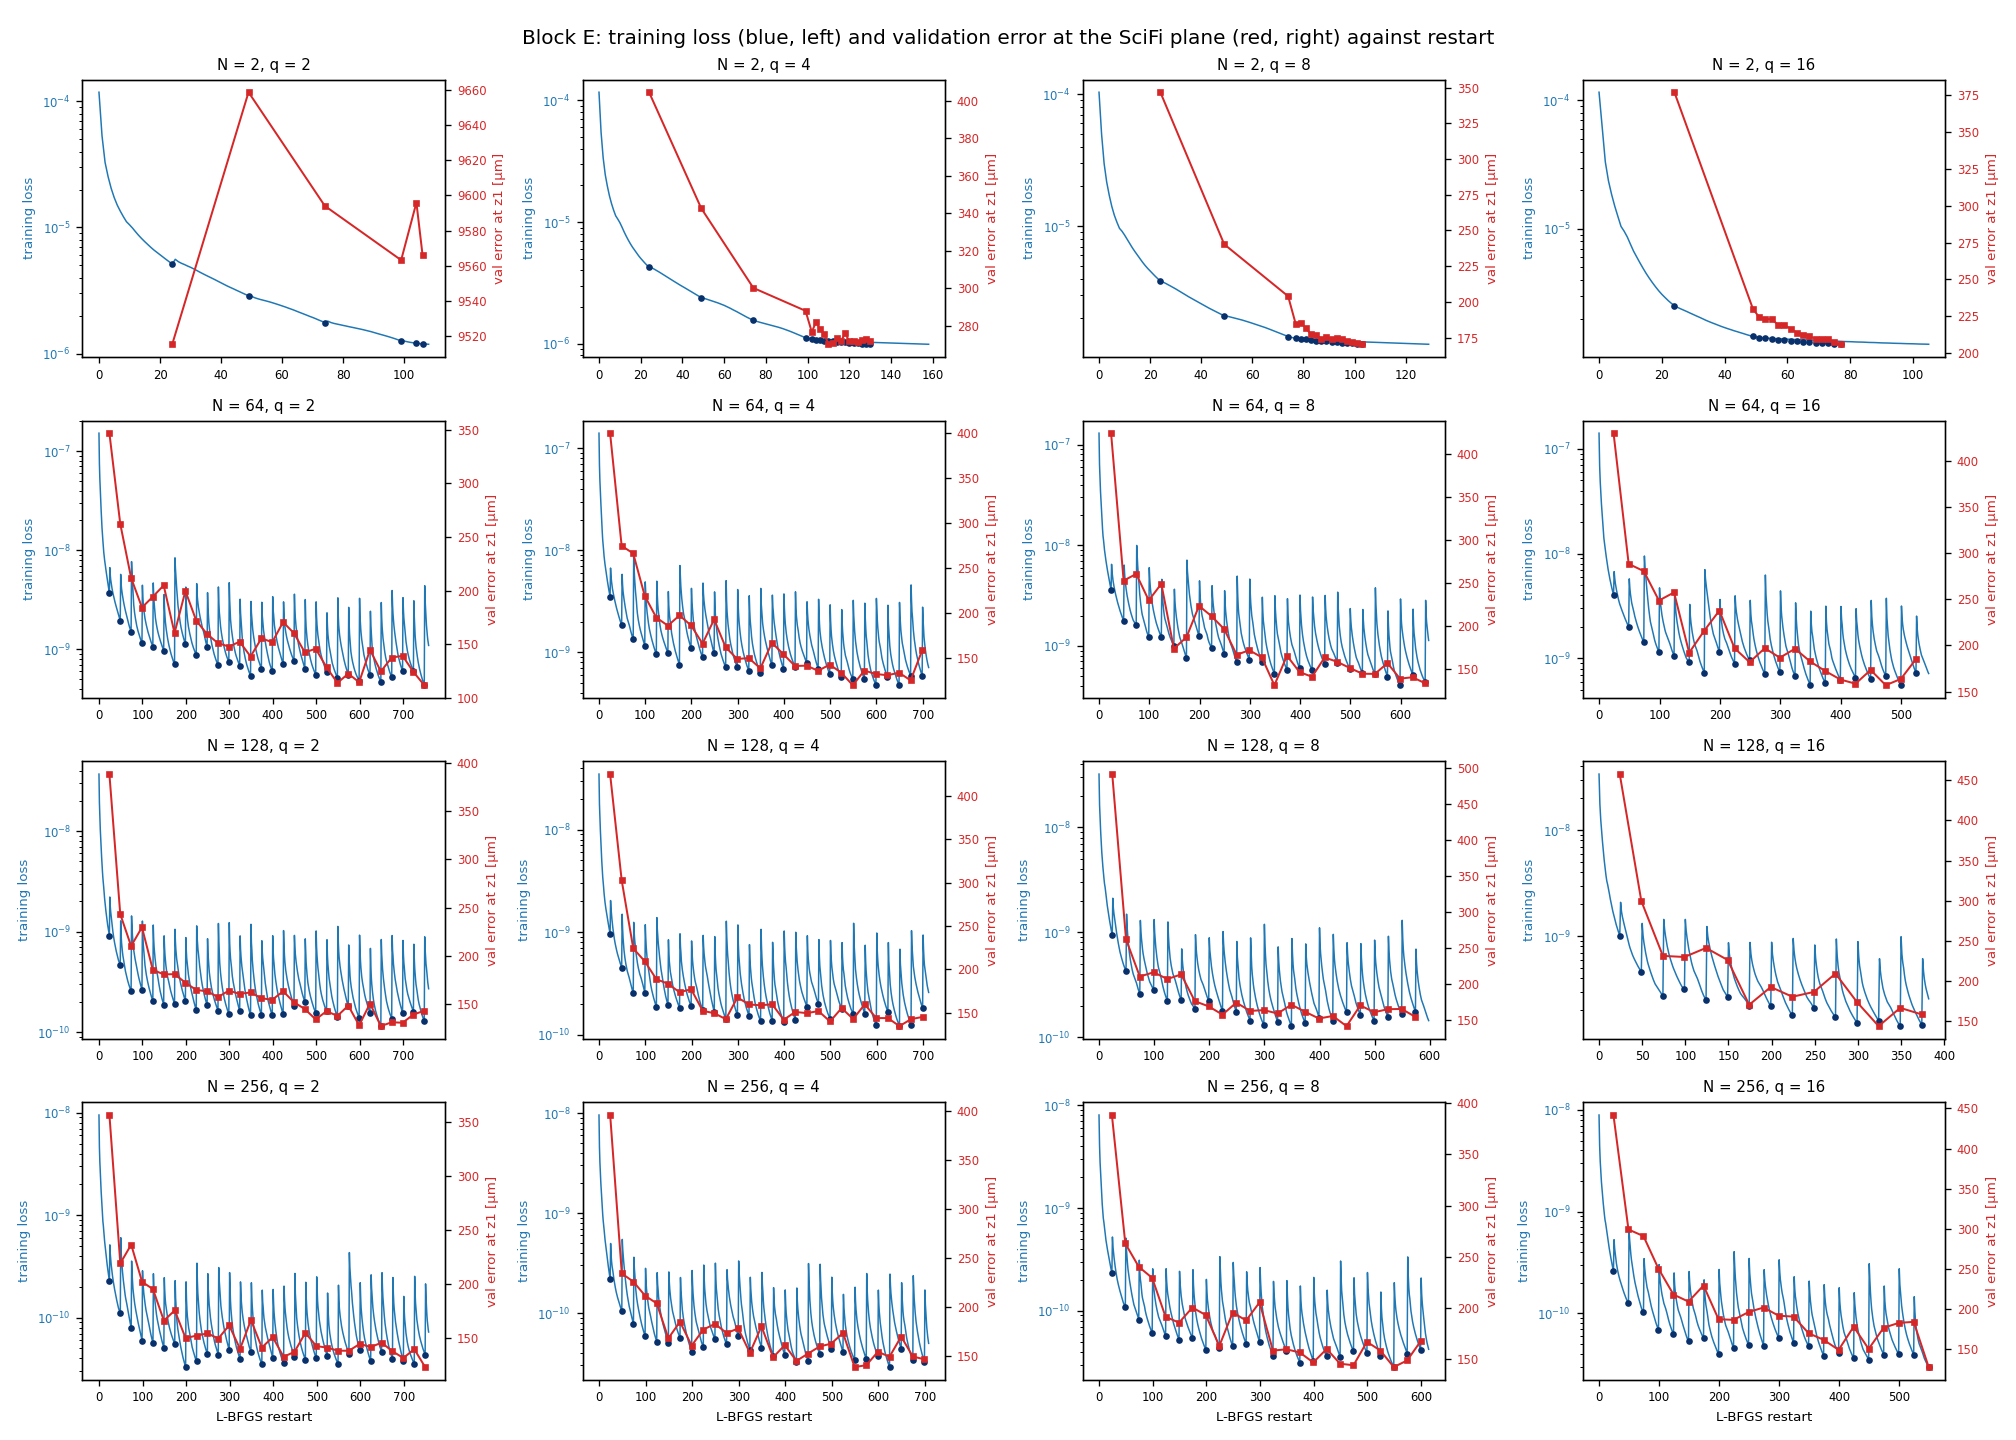

In [6]:
display(R("convergence.csv")); F("convergence_summary.png"); F("convergence_grid.png")

## 5. Over-training check (all three splits)

In [7]:
display(R("overtraining.csv")); R("split_comparison.csv").head(9)

,N,q,converged,confirmed,restarts,train_pos_med_um,val_pos_med_um,test_pos_med_um,test_over_train_pos,val_over_train_pos,train_loss,test_loss,test_over_train_loss
0,2,2,True,True,109,9632.061975,9563.498676,9249.493664,0.960282,0.992882,1.904404e-05,3.578678e-06,0.187916
1,2,4,True,False,107,268.737786,275.149907,266.444194,0.991465,1.023860,1.302966e-06,1.277151e-06,0.980188
2,2,8,True,False,82,182.783684,181.936144,181.398614,0.992422,0.995363,1.394267e-06,1.796933e-06,1.288800
3,2,16,True,False,54,212.527418,220.082681,218.145574,1.026435,1.035550,1.525954e-06,1.194188e-06,0.782584
4,64,2,False,NaN,400,151.549662,151.780858,152.793896,1.008210,1.001526,2.198380e-08,1.217152e-08,0.553659
5,64,4,False,NaN,400,155.118814,154.152236,147.835489,0.953047,0.993769,4.934441e-08,1.915564e-08,0.388203
6,64,8,False,NaN,400,148.242765,146.078955,144.194406,0.972691,0.985404,1.458950e-08,5.033352e-09,0.344998
7,64,16,False,NaN,400,164.416446,163.109713,161.911043,0.984762,0.992052,3.569962e-08,6.475360e-09,0.181385
8,128,2,False,NaN,400,152.200844,154.542672,149.470729,0.982062,1.015386,8.323938e-09,3.488628e-09,0.419108
9,128,4,False,NaN,400,141.960627,141.967325,140.095998,0.986865,1.000047,1.031685e-08,1.477512e-09,0.143213


,N,q,split,n_tracks,pos_med_um,pos_p95_um,x_med_um,y_med_um,tx_med_mrad,ty_med_mrad,loss_on_rk6_states,n_states
0,2,2,train,11567,9632.061975,39849.880593,9632.061975,184.165112,2.268107,0.053399,0.000019,23134
1,2,2,val,1463,9563.498676,44034.030042,9563.498676,199.255666,2.250228,0.053872,0.000021,2926
2,2,2,test,1452,9249.493664,39288.404824,9249.493664,176.843797,2.177687,0.053539,0.000004,2904
3,2,4,train,11567,268.737786,1833.736559,221.200431,122.456461,0.081641,0.043716,0.000001,23134
4,2,4,val,1463,275.149907,2456.725612,226.683660,118.882225,0.084022,0.043903,0.000007,2926
5,2,4,test,1452,266.444194,1977.381214,229.517029,109.928992,0.081438,0.041474,0.000001,2904
6,2,8,train,11567,182.783684,1390.565460,117.666411,115.431181,0.048603,0.044983,0.000001,23134
7,2,8,val,1463,181.936144,1818.773077,118.995519,109.842834,0.051447,0.043129,0.000005,2926
8,2,8,test,1452,181.398614,1333.276617,114.032779,114.248344,0.047639,0.043964,0.000002,2904


## 6. Case study: the best network on its own

Chosen on the validation tracks (mean error over the last eight rounds), so the test
tracks below were not used to pick it.

,what,med_um,p95_um,p99_um,max_um,frac_above_1mm
0,"this network (N = 64, q = 2)",166.258188,1.153924e+03,3.303553e+03,2.498476e+04,0.062672
1,the exact scheme at the same N and q,0.146544,1.168808e+00,1.811280e+01,1.698089e+02,0.000000
2,"Block D: one network per step, same N and q",2304.339087,1.020070e+04,1.724374e+04,6.463810e+04,0.786501
3,the straight line,450541.744575,1.252354e+06,1.448745e+06,1.832614e+06,1.000000
4,the material floor (real SciFi state vs the RK...,1896.348151,1.343206e+04,3.018207e+04,1.176342e+05,0.665978


,component,unit,p_lo,p_hi,n,med,p95,signed_mean,signed_median
0,x,µm,1.0,2.0,5,1467.166520,6224.695988,-1301.578753,-891.036391
1,x,µm,2.0,3.0,159,334.002678,1581.421274,-123.778356,-71.211879
2,x,µm,3.0,5.0,341,173.462585,1199.727871,44.328799,41.983833
3,x,µm,5.0,7.0,233,115.169993,684.874062,16.167728,9.481598
4,x,µm,7.0,10.0,197,87.900703,535.871077,-35.260489,-13.994478
5,x,µm,10.0,15.0,208,71.953117,350.770613,-68.694055,27.970808
6,x,µm,15.0,20.0,109,96.287666,672.663970,-41.088025,-8.289966
7,x,µm,20.0,30.0,115,123.814357,363.990329,-16.740850,-15.454068
8,x,µm,30.0,50.0,55,112.874252,401.729627,7.091850,44.076390
9,x,µm,50.0,100.0,24,202.149429,684.934178,19.958737,-23.186763


,group,n,med_r_um,med_p_GeV,med_eta,frac_below_5GeV,frac_above_25GeV
0,worst 5 percent,73,1939.811917,3.597041,2.284164,0.671233,0.027397
1,the rest,1379,157.450035,7.116574,3.593744,0.330674,0.095722
2,eta 2.0-2.5,158,881.489221,3.714976,2.302208,0.702532,0.000000
3,eta 2.5-3.0,255,338.123808,4.731944,2.784341,0.560784,0.003922
4,eta 3.0-3.5,292,180.252987,5.414636,3.253186,0.428082,0.030822
5,eta 3.5-4.0,302,131.417093,7.842330,3.760231,0.268212,0.086093
6,eta 4.0-4.5,249,122.153234,12.230441,4.251285,0.128514,0.180723
7,eta 4.5-5.0,196,97.975477,15.448697,4.709067,0.066327,0.270408
8,charge positive,739,184.352465,6.719738,3.539638,0.355886,0.086604
9,charge negative,713,147.674001,6.994097,3.515844,0.339411,0.098177


,p_lo,p_hi,n,loss_med,loss_share,step_med_um,chain_med_um
0,1.0,2.0,5,5.667379e-09,0.001866,2.916350,1467.889780
1,2.0,3.0,159,8.571953e-10,0.317850,1.387243,463.809539
2,3.0,5.0,341,2.320037e-10,0.651158,0.822955,241.734459
3,5.0,7.0,233,7.959688e-11,0.018632,0.488462,159.953127
4,7.0,10.0,197,4.099381e-11,0.003898,0.306515,124.220312
5,10.0,15.0,208,2.784438e-11,0.005429,0.202485,106.838572
6,15.0,20.0,109,2.645040e-11,0.000565,0.169660,118.841884
7,20.0,30.0,115,2.497931e-11,0.000218,0.212879,146.306625
8,30.0,50.0,55,4.724544e-11,0.000129,0.300810,127.423076
9,50.0,100.0,24,8.106786e-11,0.000178,0.683115,206.332337


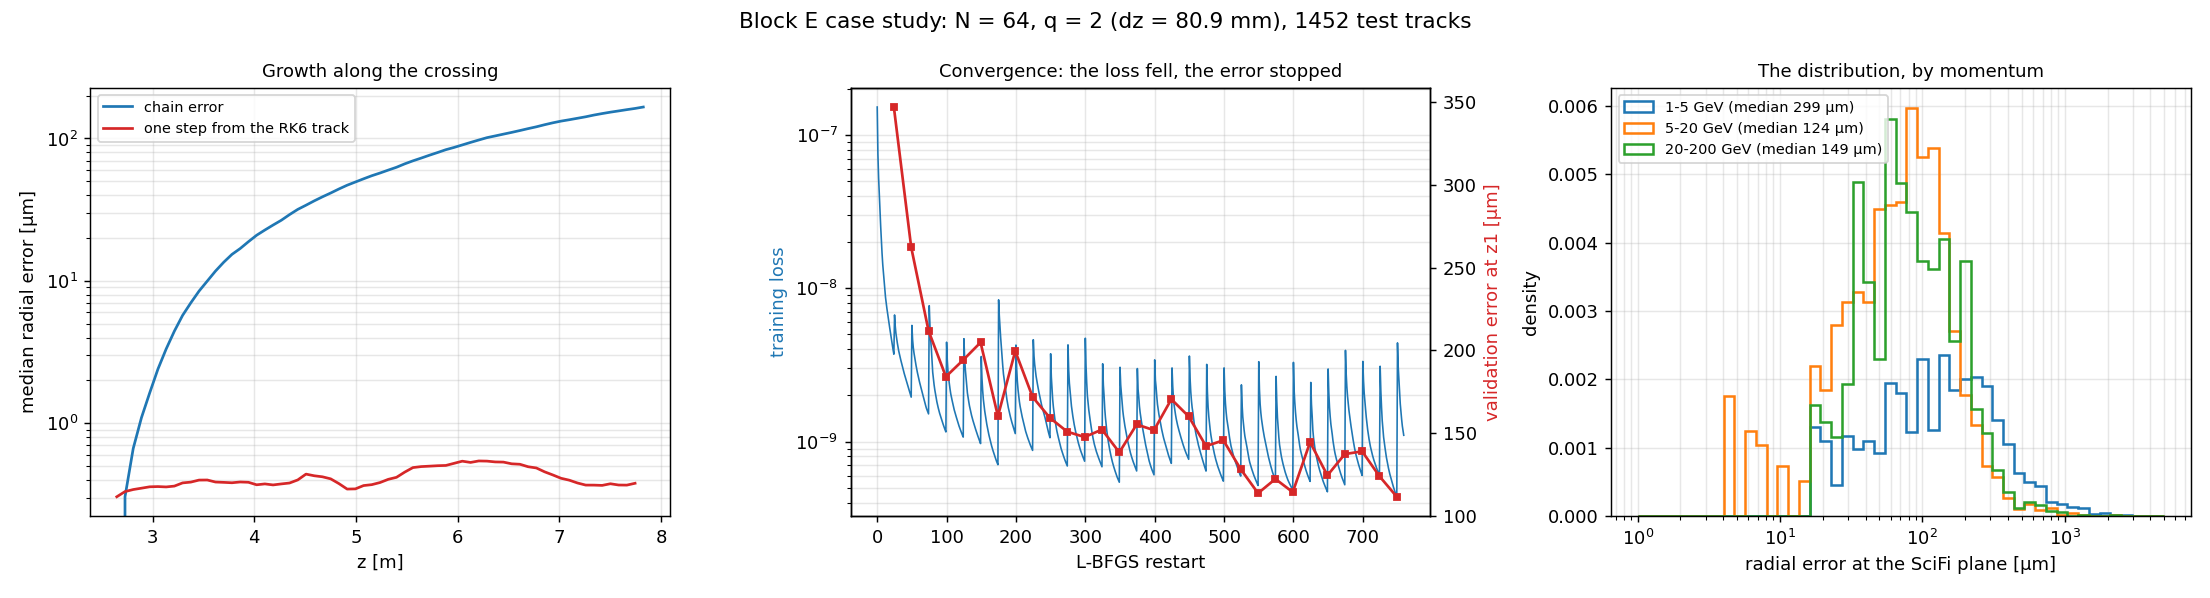

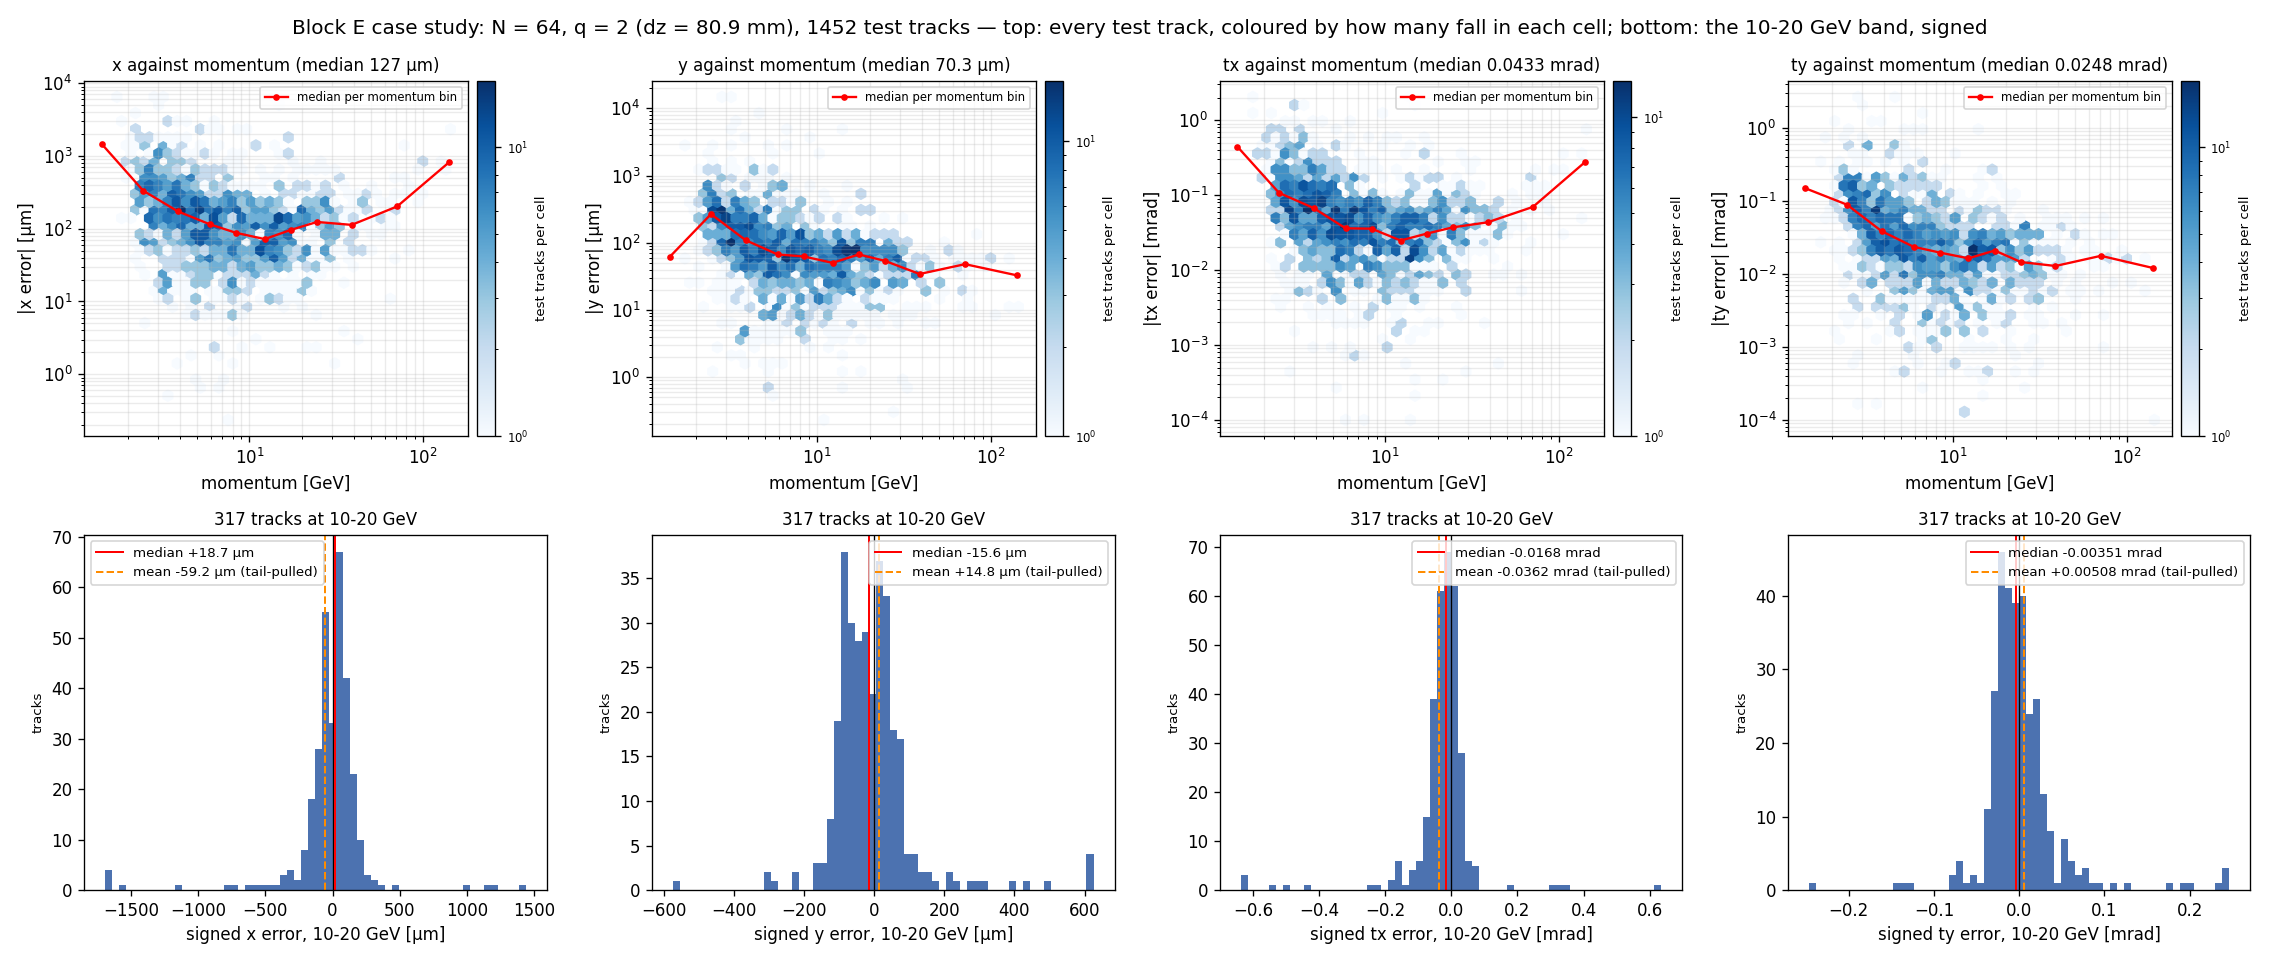

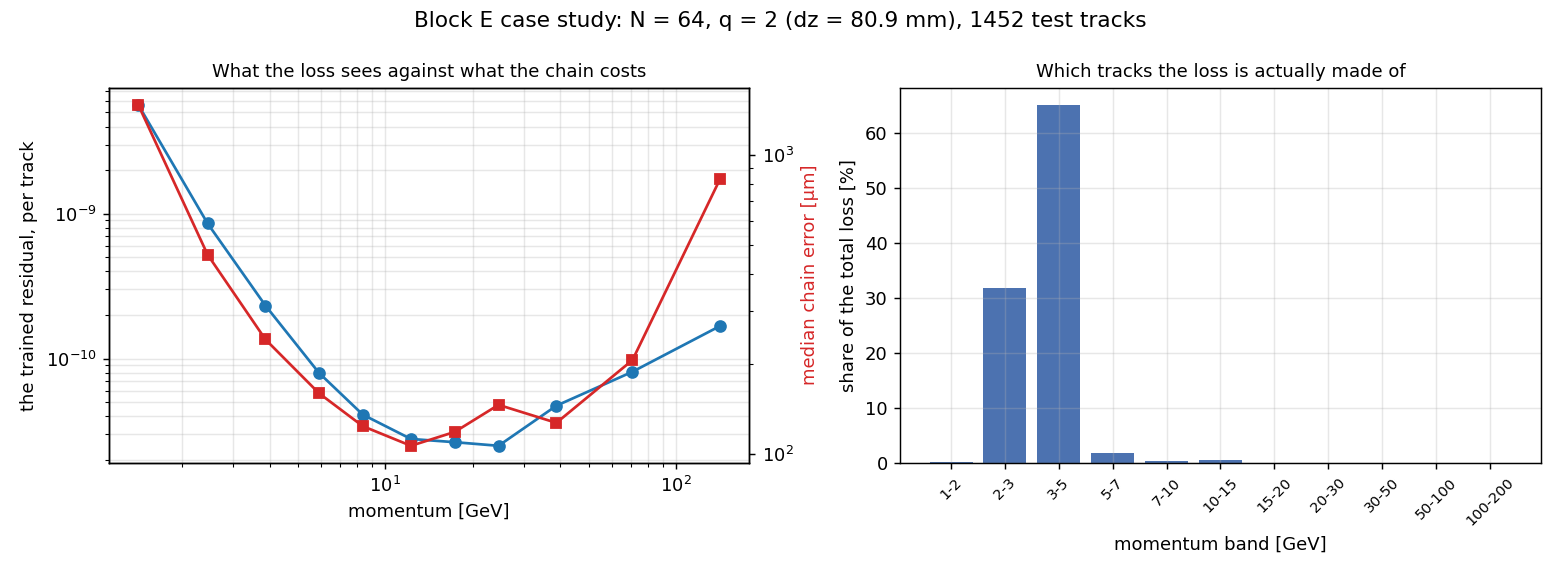

In [8]:
display(R("case_study_headline.csv")); display(R("case_study_components.csv"))
display(R("case_study_tails.csv")); display(R("case_study_loss_vs_p.csv"))
F("case_study_overview.png"); F("case_study_components.png"); F("case_study_loss_vs_p.png")

## 7. The case study with the starting x as a third axis

The same eight panels as section 6, with the track's x on the last UT plane as the extra
dimension. The flat maps hold the same numbers and are the ones to read values off.

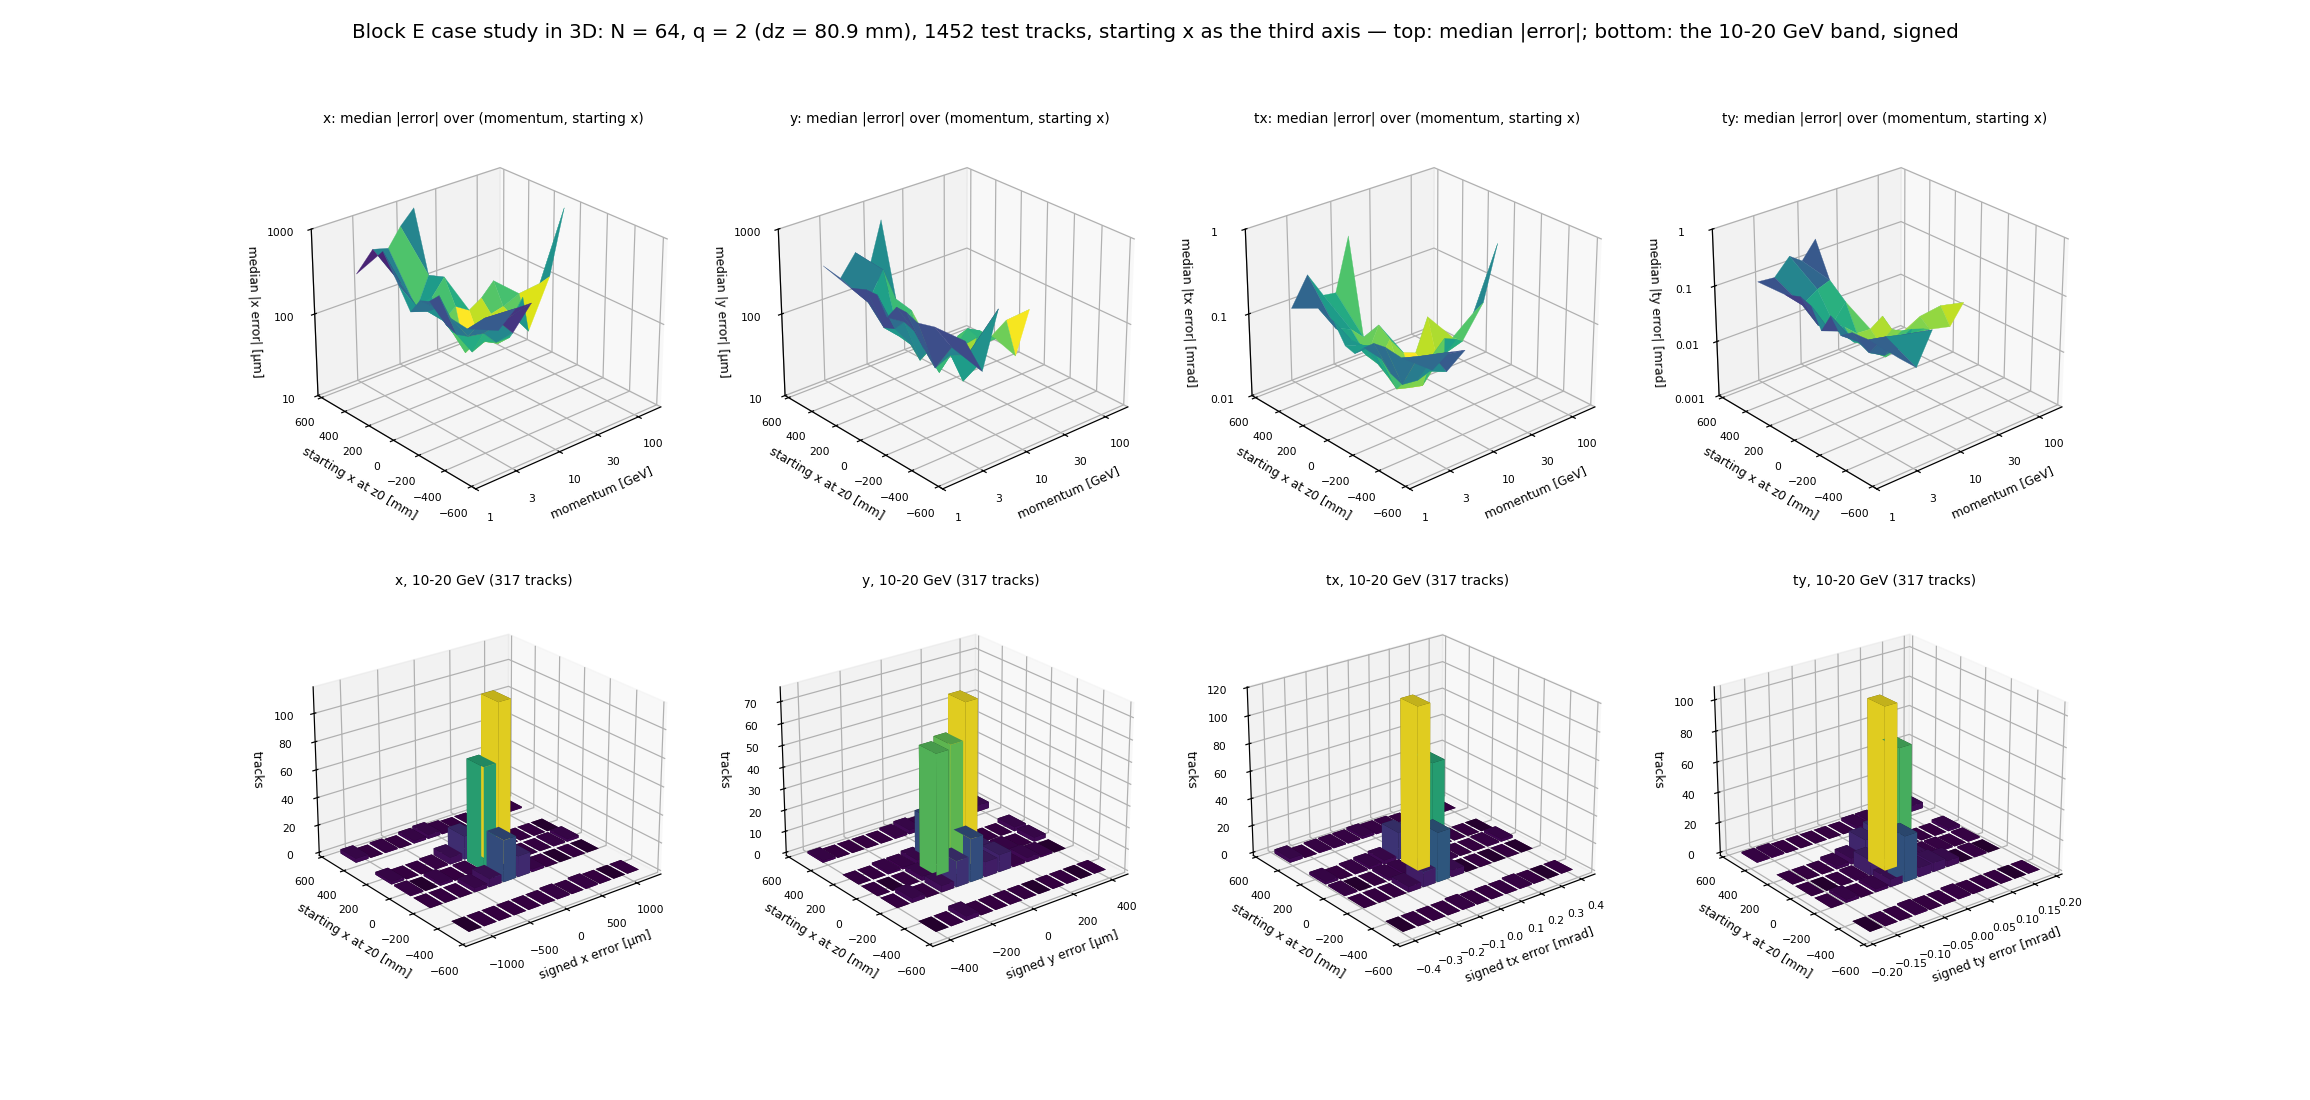

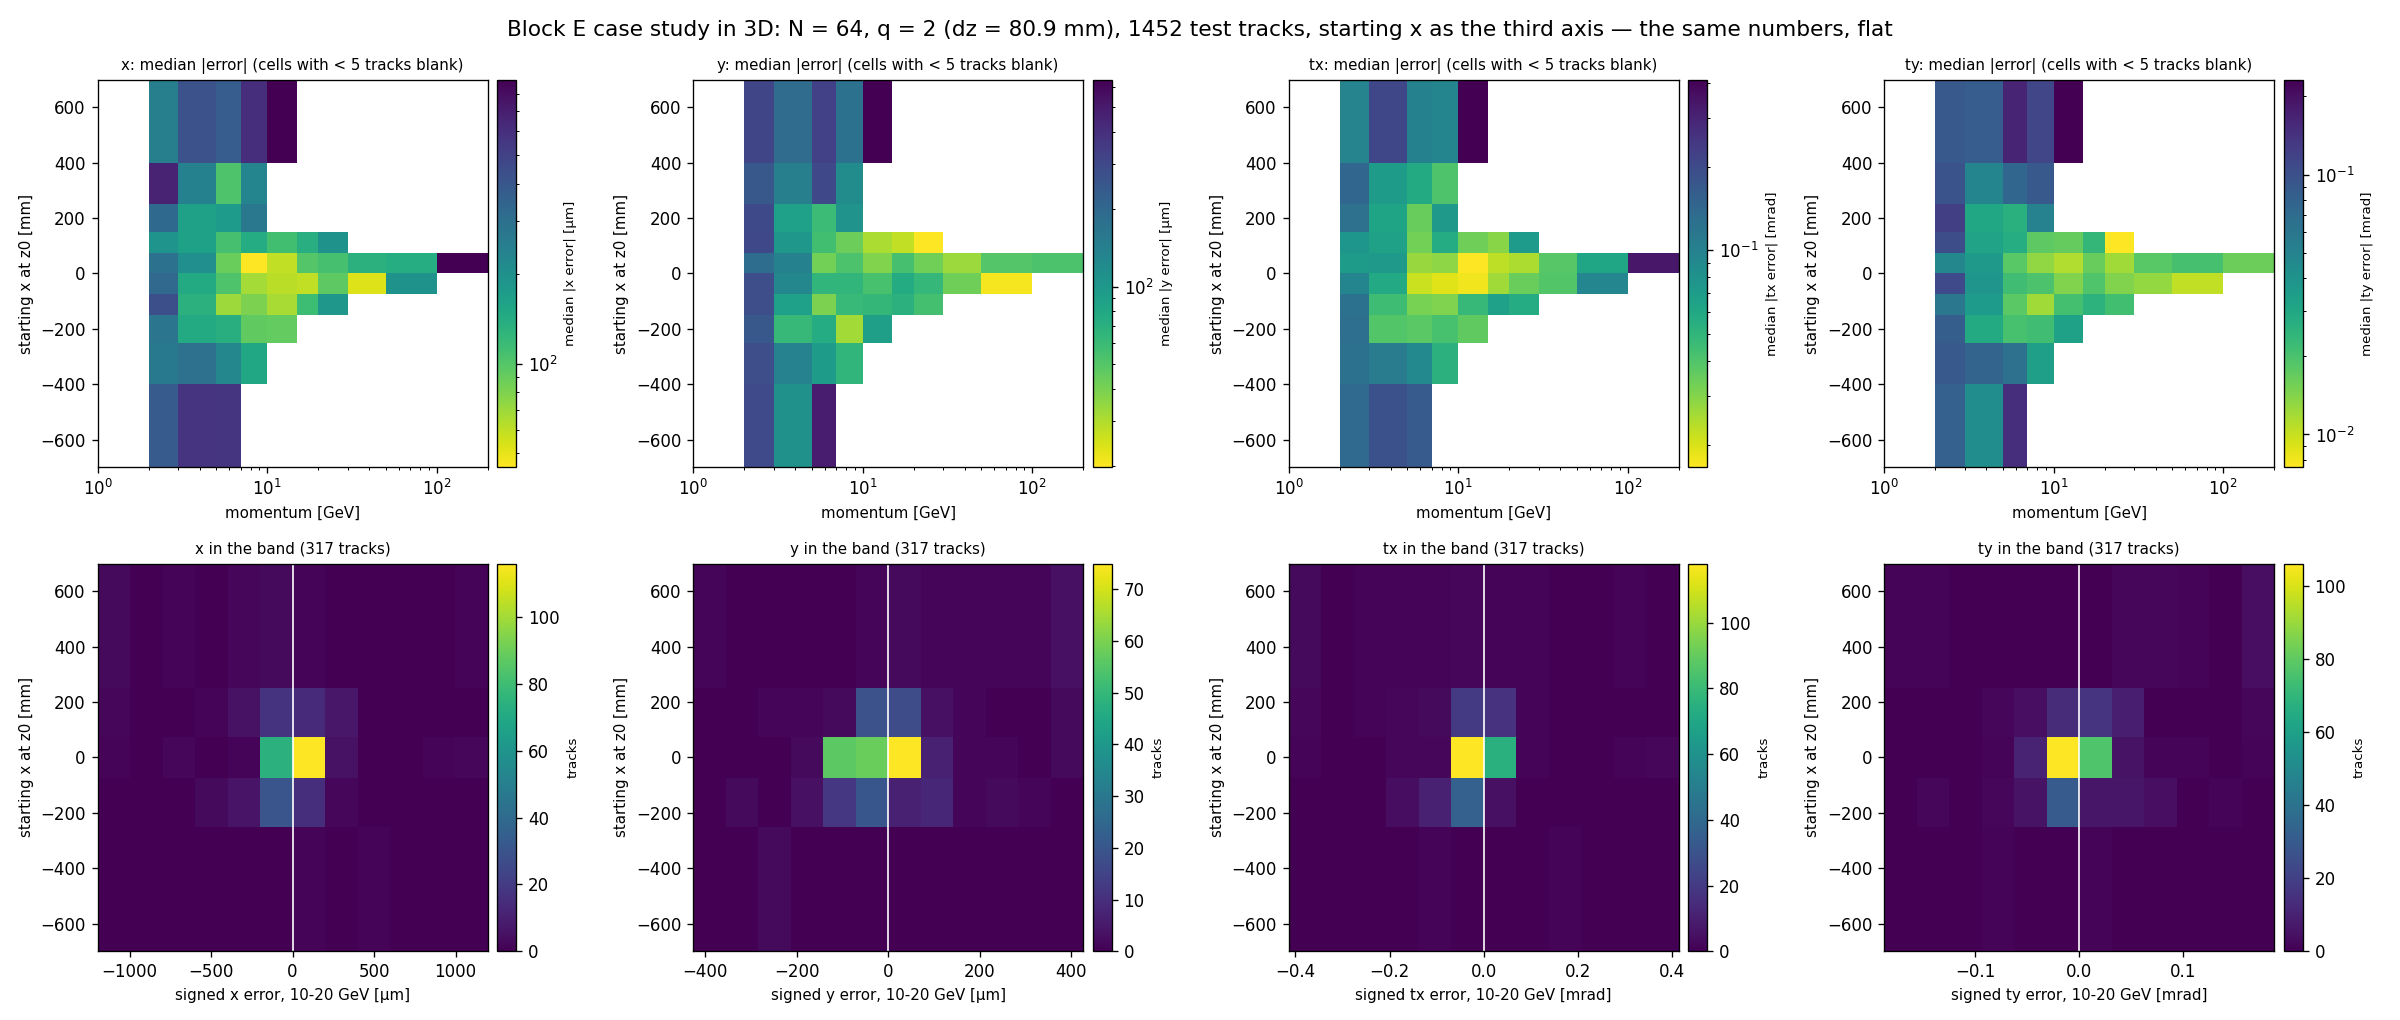

p_lo,2.0,3.0,5.0,7.0,10.0,15.0,20.0,30.0,50.0,100.0
x0_lo,,,,,,,,,,
-700.0,385.0,573.0,564.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-400.0,267.0,298.0,224.0,151.0,NaN,NaN,NaN,NaN,NaN,NaN
-250.0,281.0,146.0,135.0,93.0,92.0,NaN,NaN,NaN,NaN,NaN
-150.0,438.0,132.0,69.0,81.0,66.0,115.0,183.0,NaN,NaN,NaN
-75.0,330.0,145.0,103.0,67.0,61.0,60.0,95.0,53.0,194.0,NaN
0.0,294.0,204.0,89.0,45.0,60.0,100.0,109.0,132.0,141.0,895.0
75.0,191.0,163.0,108.0,141.0,111.0,137.0,195.0,NaN,NaN,NaN
150.0,325.0,162.0,176.0,271.0,NaN,NaN,NaN,NaN,NaN,NaN
250.0,671.0,243.0,103.0,230.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
F("case_study_components_3d.png"); F("case_study_components_x0_maps.png")
x0 = R("case_study_error_vs_p_x0.csv")
x0[(x0["component"] == "x") & (x0["n"] >= 5)].pivot(index="x0_lo", columns="p_lo", values="med").round(0)